- Inference with Oriented RCNN trained on DOTAv1.5 dataset 

In [1]:
import mmcv
from mmcv.runner import load_checkpoint
from mmdet.apis import inference_detector, show_result_pyplot
from mmrotate.models import build_detector

# Choose to use a config and initialize the detector
config = 'oriented_rcnn_r18_fpn_1x_dotav15_le90.py'
#config ='oriented_rcnn_r50_fpn_1x_dota_le90.py'

#a checkpoint file to load
checkpoint = 'latest.pth' #'oriented_rcnn_r50_fpn_1x_dota_le90-6d2b2ce0.pth'

# Load the config
config = mmcv.Config.fromfile(config)
# Set pretrained to be None since we do not need pretrained model here
config.model.pretrained = None
"""
print(config.model.type)
print(config['data']['train']['batch_size'])
"""
# Initialize the detector
model = build_detector(config.model)

# Load checkpoint
device ='cuda:0'
checkpoint = load_checkpoint(model, checkpoint, map_location=device)
# Set the classes of models for inference
model.CLASSES = checkpoint['meta']['CLASSES']
# We need to set the model's cfg for inference
model.cfg = config

# Convert the model to GPU
model.to(device)
# Convert the model into evaluation mode
model.eval()
# Use the detector to do inference
# img = 'demo/dota_demo.jpg'
# img = 'demo/sample_3.75kpixels.png'
# img = 'demo/P0427__1024__0___89.png' 
img = 'demo/P0410.jpg'
result = inference_detector(model, img)

d:\Project-MMRotate\venv_py39\lib\site-packages\mmcv\__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
d:\Project-MMRotate\venv_py39\lib\site-packages\mmdet\models\dense_heads\anchor_head.py:116: UserWarning: DeprecationWarning: `num_anchors` is deprecated, for consistency or also use `num_base_priors` instead
  warnings.warn('DeprecationWarning: `num_anchors` is deprecated, '


load checkpoint from local path: latest.pth


d:\Project-MMRotate\venv_py39\lib\site-packages\mmdet\models\dense_heads\anchor_head.py:123: UserWarning: DeprecationWarning: anchor_generator is deprecated, please use "prior_generator" instead
  warnings.warn('DeprecationWarning: anchor_generator is deprecated, '


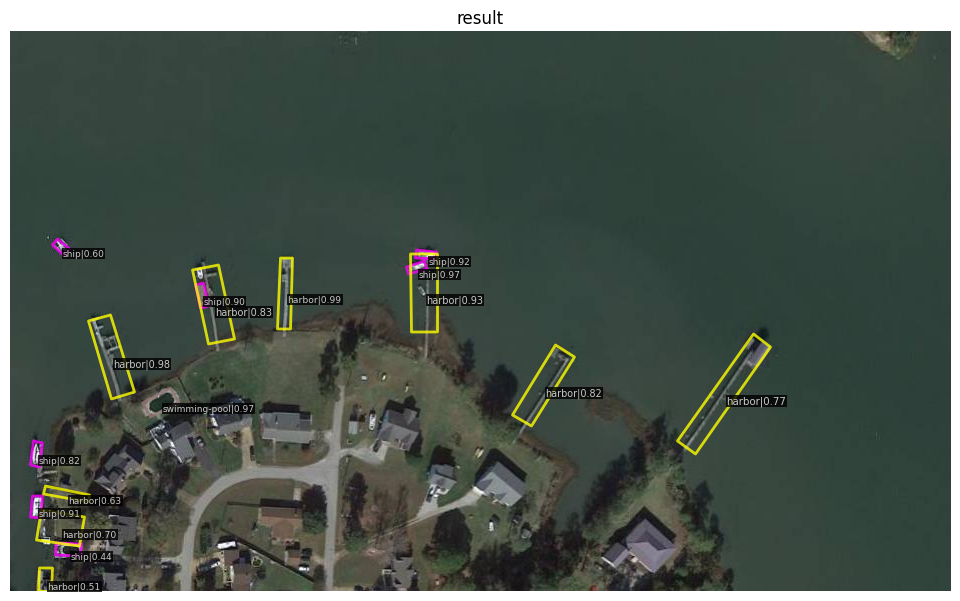

In [2]:
show_result_pyplot(model, img, result, score_thr=0.3, palette='dota')